# Cel i materiał do badań

Celem zadania była analiza dynamiki i mobilności histonu H1 z wykorzystaniem dostarczonych danych z klasycznego eksperymentu FRAP. Histon H1 pełni funkcję "spinki" dla nukleosomów, przez co wykazuje wyższą mobilność niż histony korowe.

Materiał do analizy stanowiły gotowe serie poklatkowe z mikroskopu fluorescencyjnego, obrazujące jądra­ komórek linii HeLa 21-4 (wykazujące stabilną ekspresję białka fuzyjnego H1-GFP). Na­ zdjęciach zarejestrowano proces wymiany białka po miejscowym wyblaknięciu obszaru jądra wiązką lasera. Dostarczony materiał obejmował:
- 5 klatek zarejestrowanych przed wyblaknięciem
- 46 klatek zarejestrowanych co 1 sekundę
- 57 klatek zarejestrowanych co 5 sekund aż do momentu przywrócenia fluorescencji

# Automatyzacja obróbki danych

Aby usprawnić proces analizy, przygotowano funkcję `pipeline`. Automatyzuje ona kluczowe etapy przetwarzania danych:
- wczytuje surowe wyniki CSV i usuwa ostatni, pusty pomiar pomiar
- naprawia oś czasu, uwzględniając zmianę częstotliwości robienia zdjęć (co 5 sekund zamiast co 1 sekundę po 51. klatce)
- generuje wykres punktowy pokazujący, jak wracała fluorescencja w badanym obszarze
- oblicza procentowy wskaźnik odzysku białka, porównując stan końcowy do momentu tuż po wyblaknięciu 

In [203]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

def pipeline(filename, column, label):
    df = pd.read_csv(filename)
    col_y = list(df[column])
    col_y.pop()# ostatnia klatka nie rejestruje obrazu
    col_y_scaled = []
    for i in range(len(col_y)): # po 51 klatkach, każda kolejna jest rejestrowana co 5 sekund
        if i >= 51:
            for j in range(5):
                col_y_scaled.append(col_y[i])
        else:
            col_y_scaled.append(col_y[i])
    plt.scatter(range(len(col_y_scaled)),col_y_scaled, alpha=0.3, label=label, s=8)
    plt.xlabel("czas [s]")
    plt.legend()
    return str(round(((col_y_scaled[len(col_y_scaled)-1]-col_y_scaled[5])/col_y_scaled[5])*100,2)) + "%"

# Przeprowadzona analiza

## Mean Gray Value

W pierwszej kolejności wykorzystano oprogramowanie ImageJ do wyznaczenia lokalnych zmian sygnału fluorescencyjnego. Dla zdefiniowanych, wyblakniętych obszarów na każdej klatce (na obrazkach podpisane jako 1 i 2) zmierzono średnią jasność pikseli w skali szarości (ang. Mean Gray Value). Wartość ta posłużyła jako względna, pośrednia miara intensywności fluorescencji, odzwierciedlająca zmiany lokalnego stężenia białka H1-GFP. Wyniki pomiarów wyeksportowano do pliku tekstowego (CSV) w celu dalszej ich obróbki. 

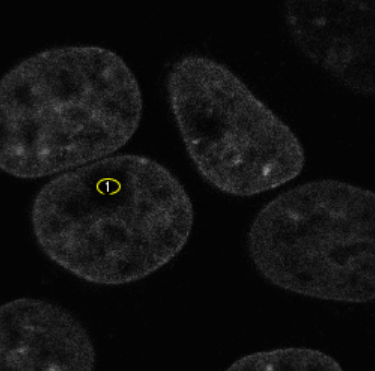 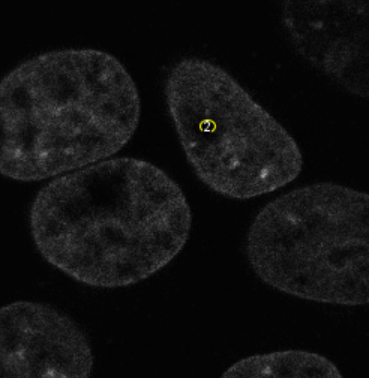

Dla każdego z jąder komórkowych (obszary 1 i 2) zastosowano wcześniej przygotowaną funkcję `pipeline`. Otrzymane wyniki zestawiono na wykresach punktowych przedstawiających zmianę wartości Mean Gray Value w czasie.

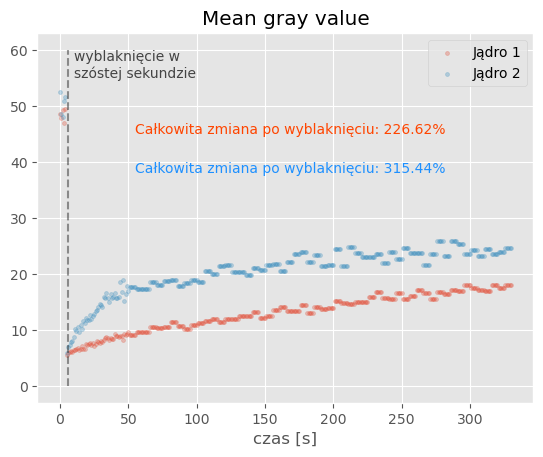

In [204]:
percentage_1 = pipeline(filename="Results8.csv", column="Mean1",label="Jądro 1")
percentage_2 = pipeline(filename="Results8.csv", column="Mean2",label="Jądro 2")
plt.title("Mean gray value")
plt.vlines(x=6, ymax=60, ymin=0, linestyles="dashed", alpha=0.4,color="black")
plt.text(10,55,"wyblaknięcie w\nszóstej sekundzie", alpha=0.7)
plt.text(55,45,"Całkowita zmiana po wyblaknięciu: " + percentage_1, color="orangered")
plt.text(55,38,"Całkowita zmiana po wyblaknięciu: " + percentage_2, color="dodgerblue")
plt.show()

Wzrost natężenia fluorescencji obserwowany po szóstej sekundzie sugeruje wysoką mobilność białka H1-GFP, które przemieszcza się z obszarów niewyblakniętych do miejsca pomiaru.  Analiza wykresu wskazuje również na różnice w czasie powrotu fluorescencji między badanymi obszarami. Jądro 2 wykazało znacznie większą dynamikę w odzyskiwaniu sygnału (zmiana na poziomie 315%), co może wskazywać na wyższą mobilność białka H1-GFP w tym regionie w porównaniu do jądra 1 (226%). 

## Integrated Density

W następnej kolejności wykonano pomiar parametru Integrated Density bezpośrednio w miejscach poddanych fotowyblaknięciu pozwolił na ocenę tempa powrotu sygnału fluorescencyjnego.

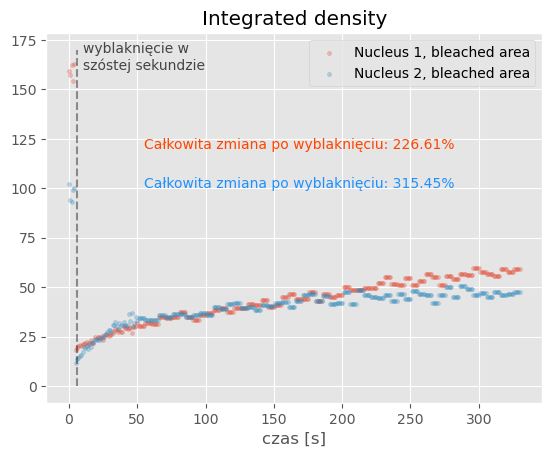

In [205]:
percentage_1 = pipeline(filename="Results8.csv", column="IntDen1",label="Nucleus 1, bleached area")
percentage_2 = pipeline(filename="Results8.csv", column="IntDen2",label="Nucleus 2, bleached area")
plt.title("Integrated density")
plt.vlines(x=6, ymax=170, ymin=0, linestyles="dashed", alpha=0.4,color="black")
plt.text(10,160,"wyblaknięcie w\nszóstej sekundzie", alpha=0.7)
plt.text(55,120,"Całkowita zmiana po wyblaknięciu: " + percentage_1, color="orangered")
plt.text(55,100,"Całkowita zmiana po wyblaknięciu: " + percentage_2, color="dodgerblue")
plt.show()

Na wykresie zaobserwowano wzrost natężenia sygnału tuż po szóstej sekundzie, osiągający 226,61% dla jądra 1 oraz 315,45% dla jądra 2. Tak znaczący przyrost zintegrowanej gęstości w lokalnym punkcie jest wynikiem napływu cząsteczek białka H1-GFP z pozostałych, jasnych części jądra do obszaru objętego wyblaknięciem.

## Integrated density dla wybranego obszaru poza wyblaknięciem

Wykonano również analizę obszaru wewnątrz jądra 1, który nie został poddany bezpośredniemu działaniu wiązki lasera. Służy ona jako punkt odniesienia dla procesów zachodzących w komórce.


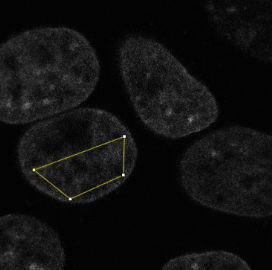

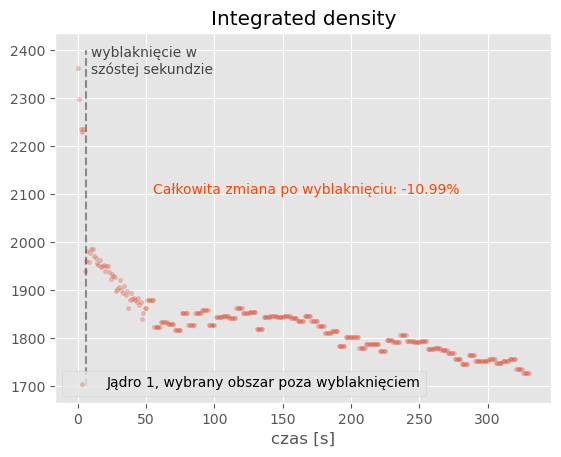

In [206]:
percentage_1 = pipeline(filename="Results7.csv", column="IntDen1",label="Jądro 1, wybrany obszar poza wyblaknięciem")
plt.title("Integrated density")
plt.vlines(x=6, ymax=2400, ymin=1700, linestyles="dashed", alpha=0.4,color="black")
plt.text(10,2350,"wyblaknięcie w\nszóstej sekundzie", alpha=0.7)
plt.text(55,2100,"Całkowita zmiana po wyblaknięciu: " + percentage_1, color="orangered")
plt.show()

W przeciwieństwie do obszarów wygaszonych, tutaj odnotowano spadek sygnału o 10,99%. Dowodzi to, że wzrost fluorescencji w strefach wyblakniętych wynika z migracji białek ze stref nieobjętych działaniem lasera, a nie z błedu aparatury.

## Integrated density dla całych dwóch jąder

Ostatni etap analizy objął pomiar całkowitej fluorescencji obu badanych jąder w cazsie trwania całego eksperymentu. 


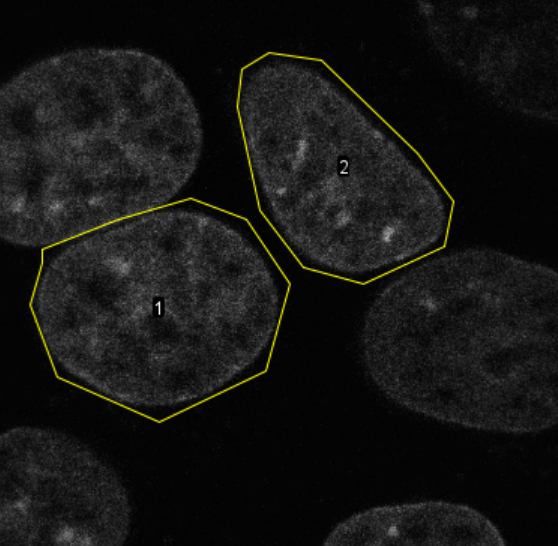


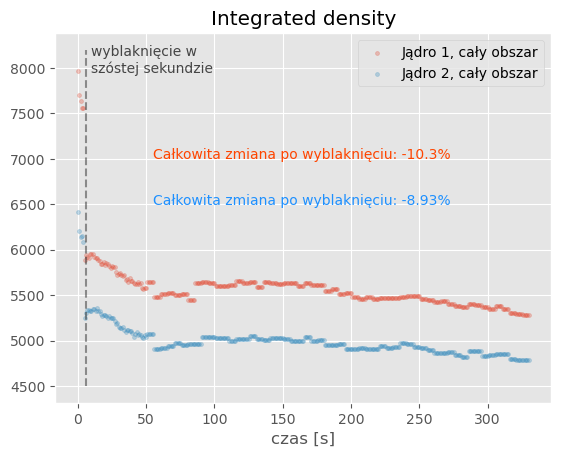

In [207]:
percentage_1 = pipeline(filename="Results9.csv", column="IntDen1",label="Jądro 1, cały obszar")
percentage_2 = pipeline(filename="Results9.csv", column="IntDen2",label="Jądro 2, cały obszar")
plt.title("Integrated density")
plt.vlines(x=6, ymax=8200, ymin=4500, linestyles="dashed", alpha=0.4,color="black")
plt.text(10,7950,"wyblaknięcie w\nszóstej sekundzie", alpha=0.7)
plt.text(55,7000,"Całkowita zmiana po wyblaknięciu: " + percentage_1, color="orangered")
plt.text(55,6500,"Całkowita zmiana po wyblaknięciu: " + percentage_2, color="dodgerblue")
plt.show()

Dla obu jąder odnotowano niewielki spadek całkowitej jasności (odpowiednio -10,3% oraz -8,93%). Porównanie tego wyniku z danymi lokalnymi sugeruje, że skoro całkowity sygnał w jądrze maleje, a w punkcie wyblaknięcia rośnie, mamy do czynienia z przemieszczaniem się białka wewnątrz jądra. Dowodzi to, że białko H1-GFP jest mobilne i przemieszcza się swobodnie w obrębie jądra, wyrównując różnice w natężeniu fluorescencji powstałe na skutek fotowyblaknięcia.

# Podsumowanie

Połączenie wszystkich powyższych analiz potwierdza mobilność białka H1-GFP. Wykazano, że powrót sygnału w miejscu wyblaknięcia odbywa się kosztem fluorescencji z pozostałych obszarów jądra, co jest dowodem na dyfuzje badanych białek.